In [24]:
import pandas as pd
df_clus=pd.read_csv('df_clus.csv')
df_clus2=pd.read_csv('df_clus.csv')

In [25]:
df_clus.head()

,Precio,Expensas,Barrio,Dormitorios,Banos,Ambientes,Antiguedad,Sup_Cubierta_m2,Sup_Total_m2,Latitud,...,Luminoso,Balcon_Aterrazado,A_Estrenar,Precio_m2,Proporcion_Cubierta,Indice_Seguridad,Categoria_Seguridad,Subte_Cerca,Percentil_Precio_Barrio,Score
0,146000,170000,Saavedra,2.0,1.0,3.0,NaN,55.0,55.0,-34.539597,...,0,1,1,2654.545455,1.000000,0.763811,Segura,0.0,0.646853,4.0
1,75000,130000,Saavedra,1.0,1.0,1.0,9.0,26.0,31.0,-34.554790,...,1,1,0,2419.354839,0.838710,0.831413,Segura,0.0,0.513986,3.5
2,205000,300000,Saavedra,1.0,1.0,2.0,10.0,54.0,90.0,-34.547070,...,1,1,0,2277.777778,0.600000,0.952655,Muy Segura,0.0,0.433566,6.0
3,85000,55000,Saavedra,1.0,1.0,1.0,NaN,33.0,33.0,-34.555390,...,0,0,1,2575.757576,1.000000,0.867708,Segura,0.0,0.611888,1.0
4,169000,90000,Saavedra,2.0,1.0,3.0,NaN,70.0,77.0,-34.544040,...,1,1,1,2194.805195,0.909091,0.950754,Muy Segura,0.0,0.382867,5.0


In [26]:
df_clus.shape

(10176, 28)

In [27]:
nulos_df = pd.DataFrame({
    'nulos': df_clus.isna().sum(),
    'porcentaje': df_clus.isna().mean() * 100
})

nulos_df = nulos_df[nulos_df['nulos'] > 0].sort_values(by='porcentaje', ascending=False)

print(nulos_df)

                     nulos  porcentaje
Categoria_Seguridad   1759   17.285770
Indice_Seguridad      1759   17.285770
Subte_Cerca           1759   17.285770
Antiguedad            1662   16.332547
Latitud               1101   10.819575
Longitud              1079   10.603381


In [28]:
df_clus['Indice_Seguridad'] = df_clus.groupby('Barrio')['Indice_Seguridad']\
    .transform(lambda x: x.fillna(x.median()))

In [29]:
df_clus = df_clus.drop(columns=['Link','Latitud', 'Longitud', 'Subte_Cerca', 'Categoria_Seguridad', 'Precio', 'Sup_Total_m2'])

# Convertir NA a NaN real (por si quedó como string)
df_clus = df_clus.replace('<NA>', pd.NA)

# Convertir todo lo posible a numérico
df_clus = df_clus.apply(pd.to_numeric, errors='ignore')

C:\Users\matif\AppData\Local\Temp\ipykernel_7404\2775362201.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_clus = df_clus.apply(pd.to_numeric, errors='ignore')


In [30]:
df_clus = pd.get_dummies(df_clus, columns=['Barrio'], drop_first=True)

In [31]:
df_clus = df_clus.dropna(subset=['Antiguedad']).reset_index(drop=True)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clus)

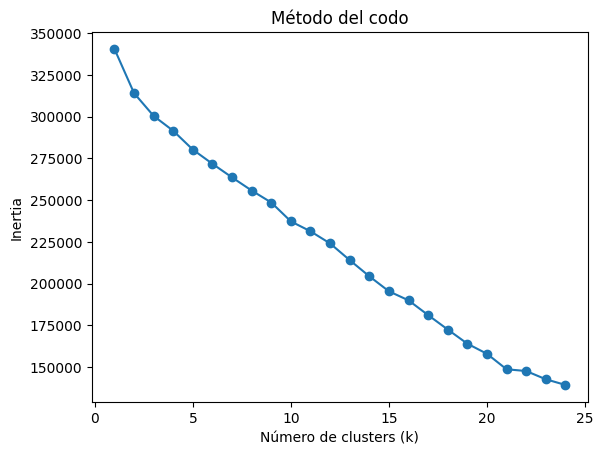

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 25):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 25), inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia')
plt.title('Método del codo')
plt.show()

k = 2, silhouette = 0.1304
k = 3, silhouette = 0.0933
k = 4, silhouette = 0.0417
k = 5, silhouette = 0.0978
k = 6, silhouette = 0.0622
k = 7, silhouette = 0.0827
k = 8, silhouette = 0.1066
k = 9, silhouette = 0.1146
k = 10, silhouette = 0.1309
k = 11, silhouette = 0.1488
k = 12, silhouette = 0.1567
k = 13, silhouette = 0.1856
k = 14, silhouette = 0.1975
k = 15, silhouette = 0.2147
k = 16, silhouette = 0.2227
k = 17, silhouette = 0.2583
k = 18, silhouette = 0.2490
k = 19, silhouette = 0.2732
k = 20, silhouette = 0.2867
k = 21, silhouette = 0.2788
k = 22, silhouette = 0.2858
k = 23, silhouette = 0.2372
k = 24, silhouette = 0.2333


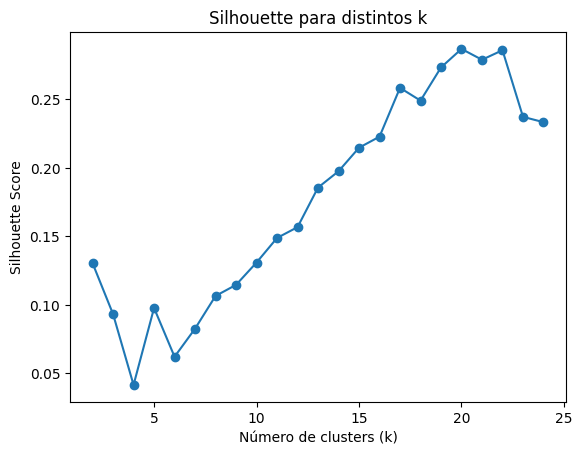

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 25) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"k = {k}, silhouette = {score:.4f}")

plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette para distintos k')
plt.show()

In [35]:
k_optimo = 20

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clus['cluster'] = clusters

In [36]:
df_clus.groupby('cluster').mean(numeric_only=True)\
       .sort_values(by='Precio_m2', ascending=False)

,Expensas,Dormitorios,Banos,Ambientes,Antiguedad,Sup_Cubierta_m2,Amenities,Losa_Central,Aire_Acond,Apto_Credito,...,Barrio_Palermo,Barrio_Parque Patricios,Barrio_Puerto Madero,Barrio_Recoleta,Barrio_Retiro,Barrio_Saavedra,Barrio_San Nicolás,Barrio_San Telmo,Barrio_Villa Urquiza,Barrio_Villa del Parque
cluster,,,,,,,,,,,,,,,,,,,,,
8,497064.816514,1.646789,1.692661,2.513761,14.068807,87.371560,0.866972,0.119266,0.348624,0.362385,...,0.000000,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14,236324.078512,1.714876,1.334711,2.615702,26.756198,60.322314,0.475207,0.157025,0.264463,0.549587,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,240225.509058,1.719203,1.355072,2.559783,35.780797,60.230072,0.367754,0.112319,0.226449,0.523551,...,1.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
18,253441.154661,1.853814,1.351695,2.733051,36.584746,62.576271,0.296610,0.137712,0.266949,0.550847,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,587690.834043,3.314894,2.753191,4.538298,41.997872,150.995745,0.457447,0.342553,0.248936,0.453191,...,0.125532,0.0,0.0,0.219149,0.155319,0.010638,0.023404,0.002128,0.025532,0.006383
9,239342.847561,1.772358,1.408537,2.585366,45.995935,65.481707,0.205285,0.111789,0.241870,0.536585,...,0.000000,0.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,180090.953623,1.605797,1.249275,2.411594,26.133333,52.495652,0.373913,0.052174,0.228986,0.611594,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
15,160864.463054,1.438424,1.152709,2.152709,28.325123,49.669951,0.714286,0.064039,0.305419,0.527094,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17,230758.201285,1.546039,1.218415,2.321199,50.794433,57.933619,0.411135,0.104925,0.259101,0.471092,...,0.000000,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000


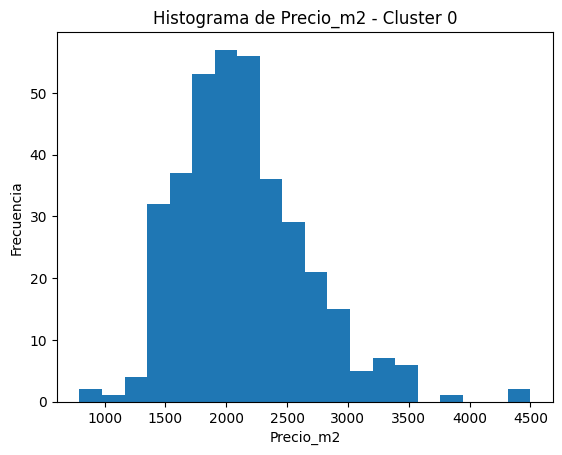

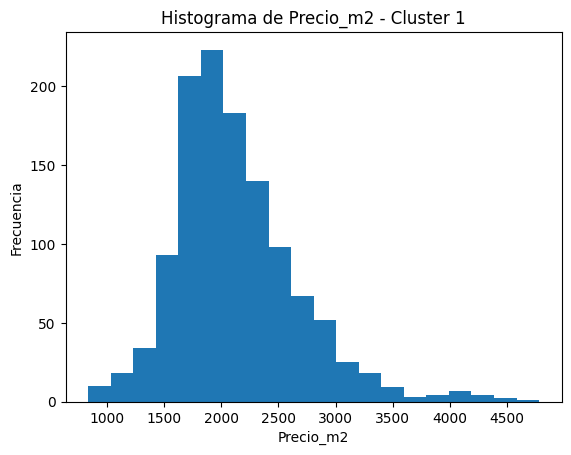

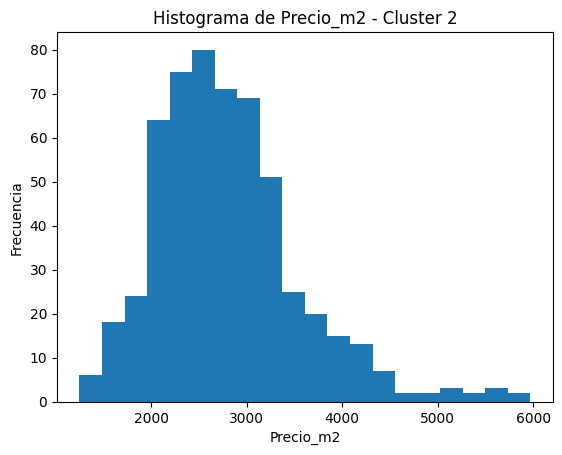

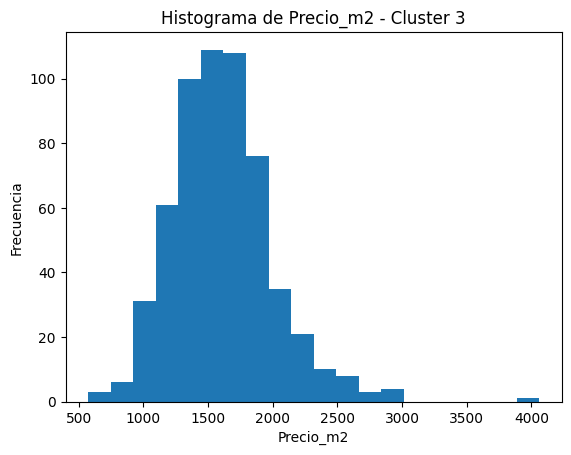

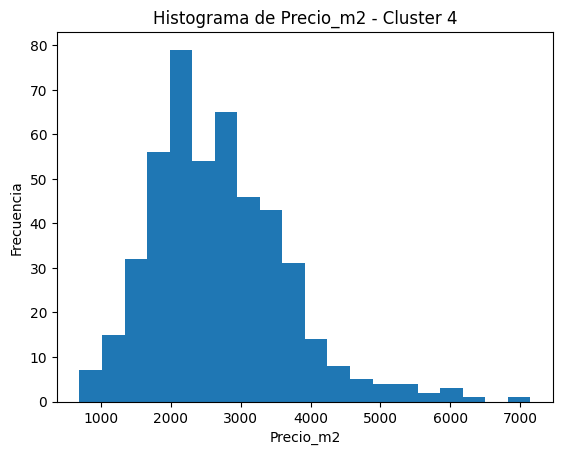

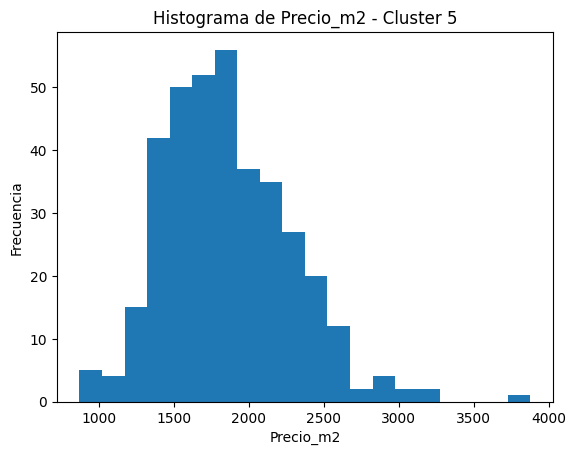

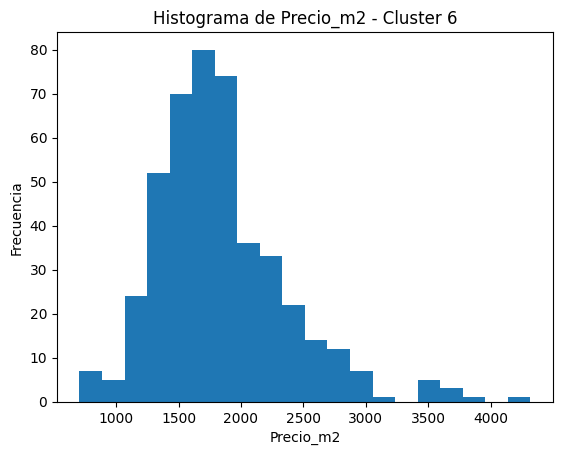

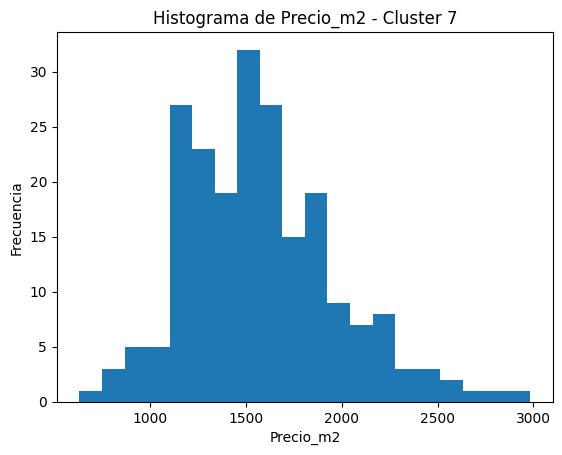

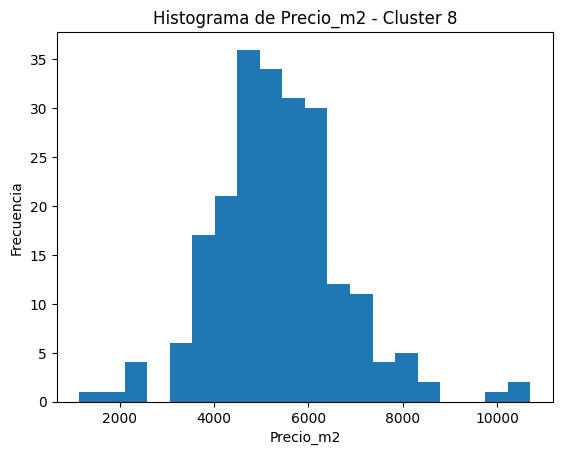

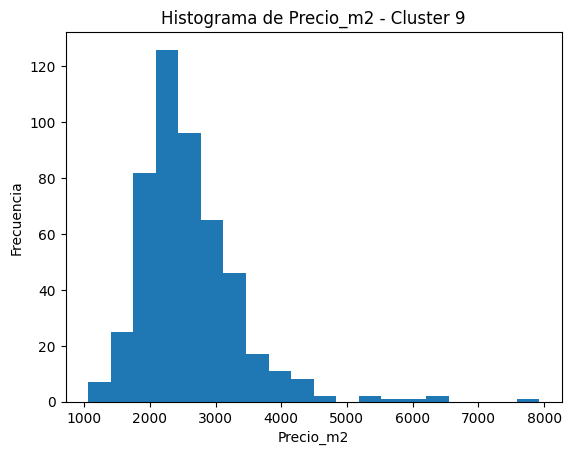

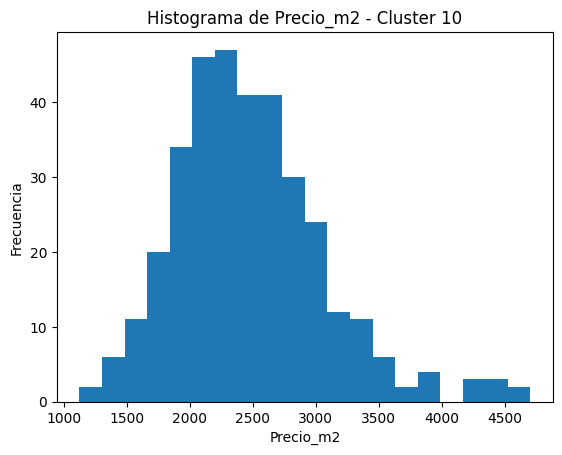

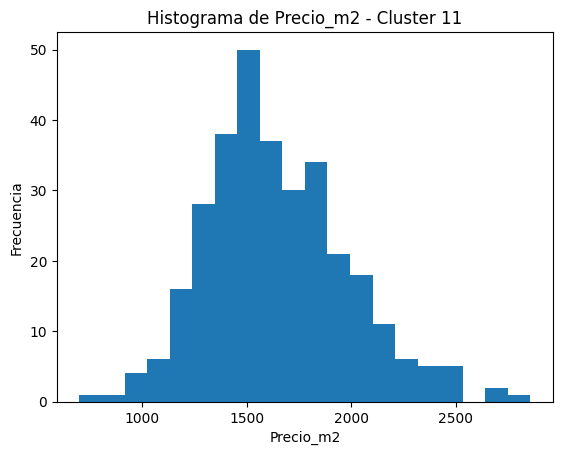

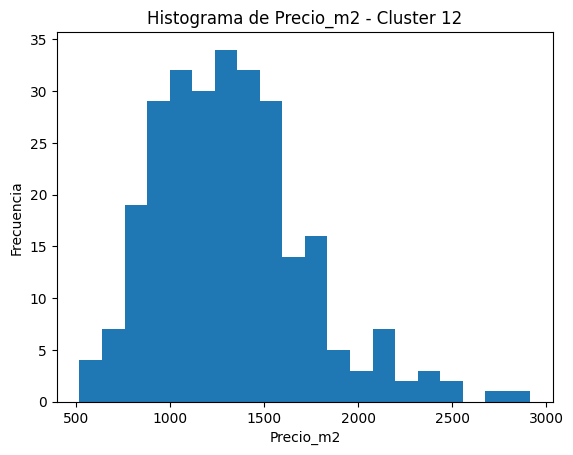

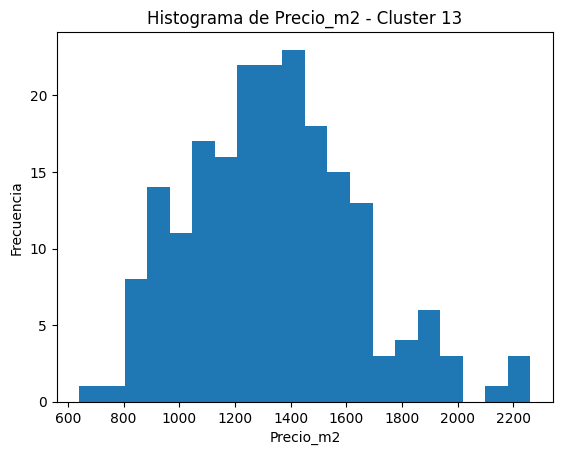

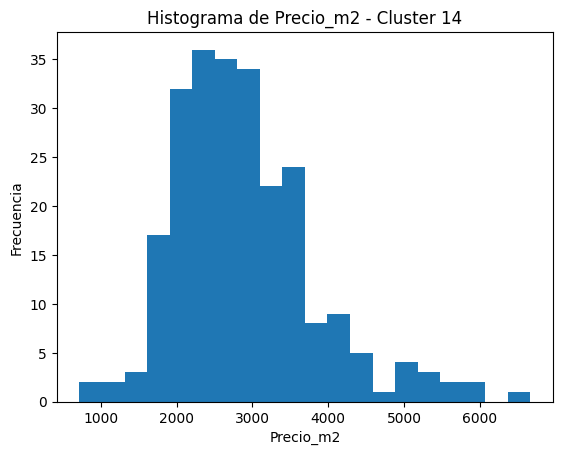

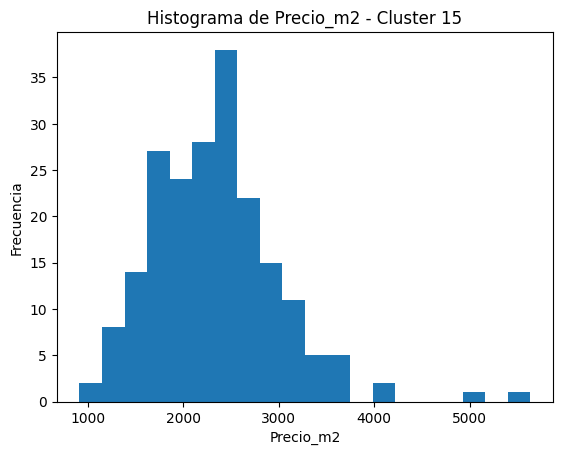

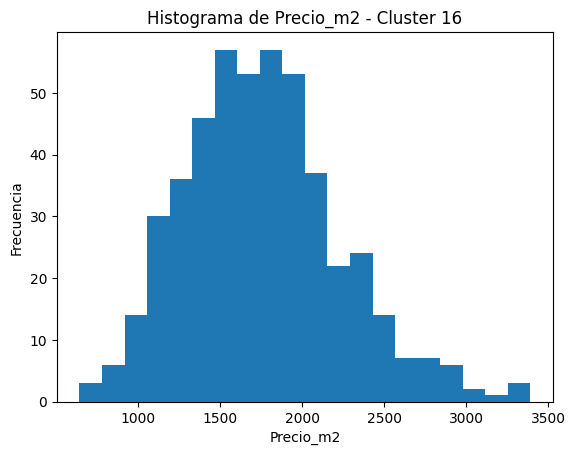

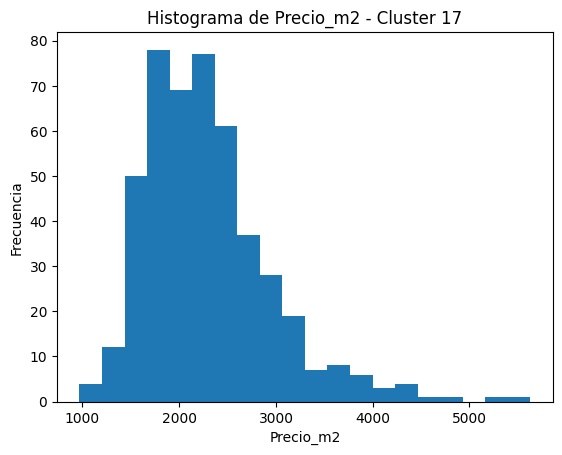

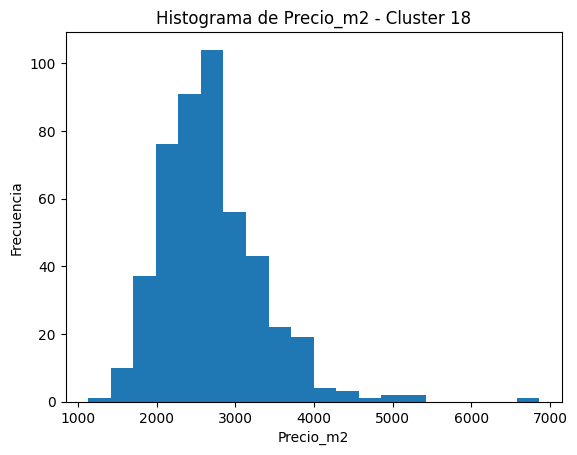

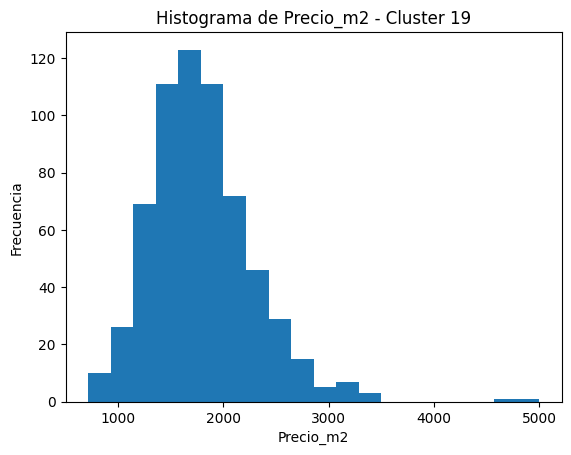

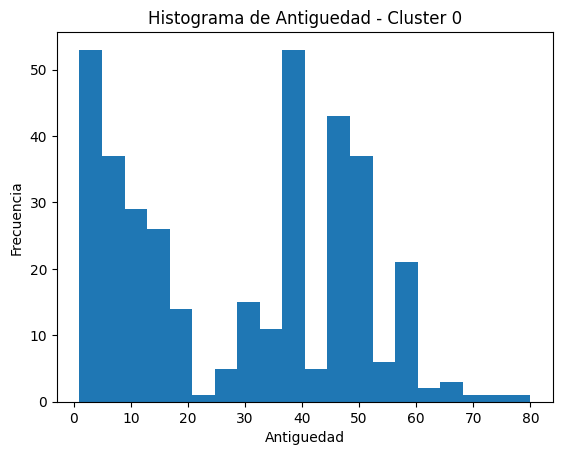

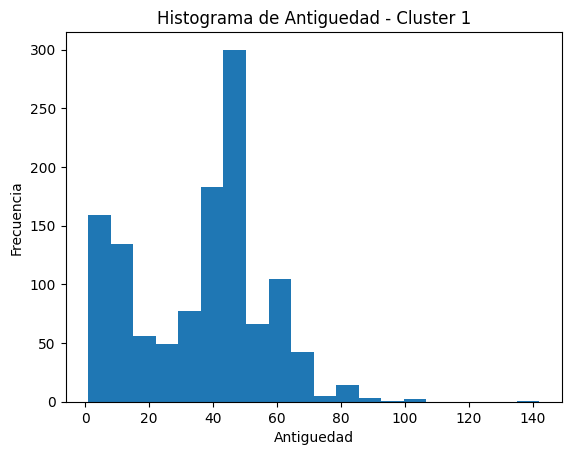

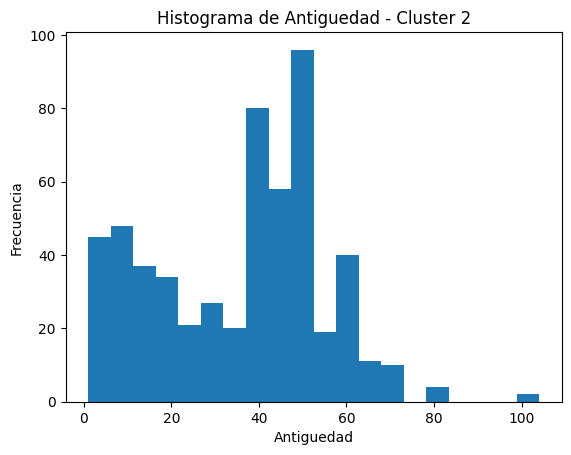

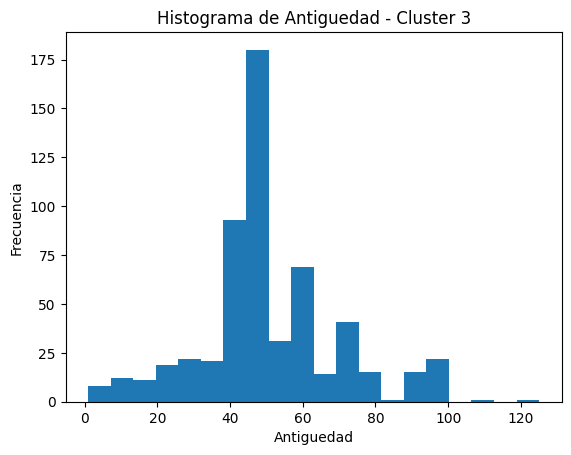

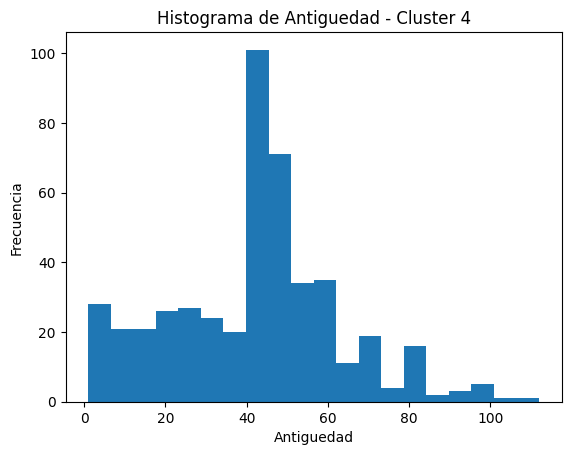

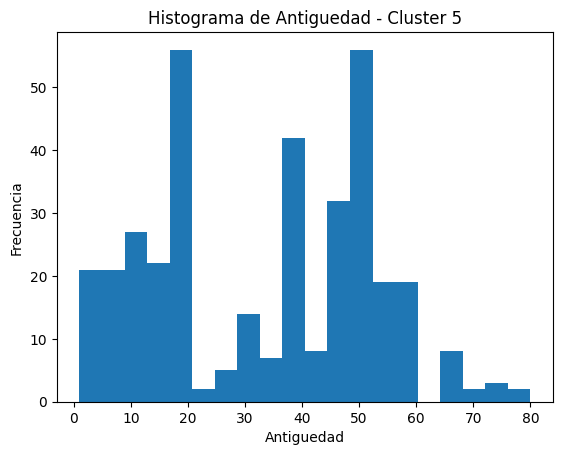

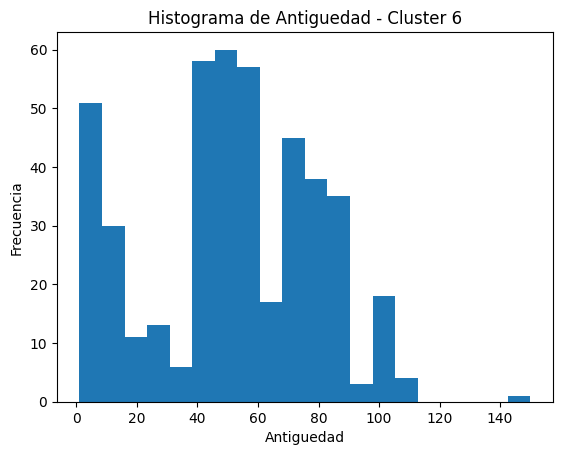

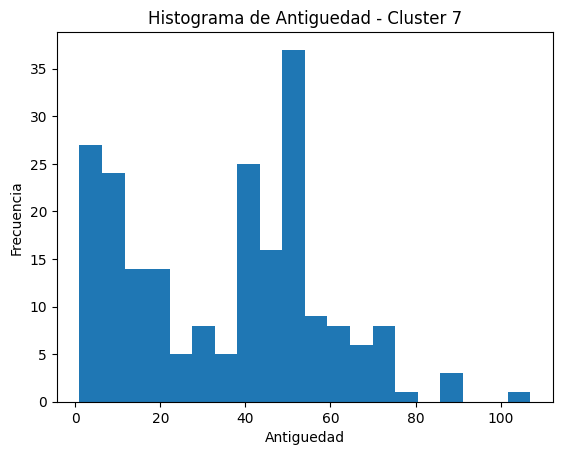

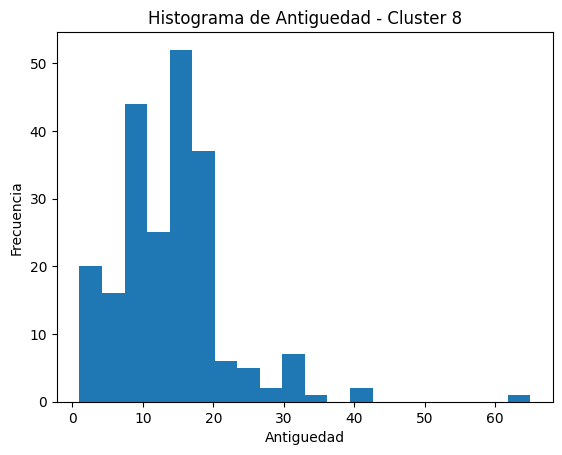

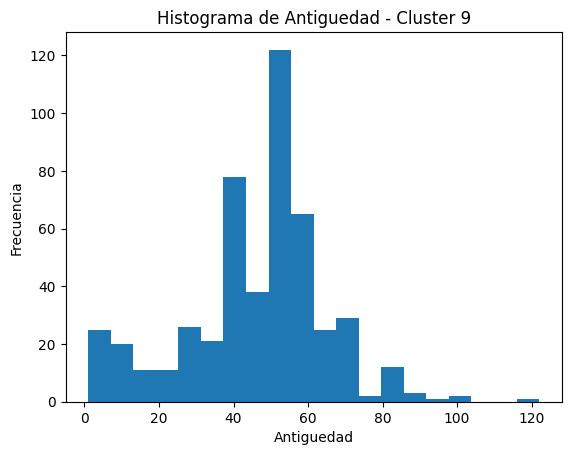

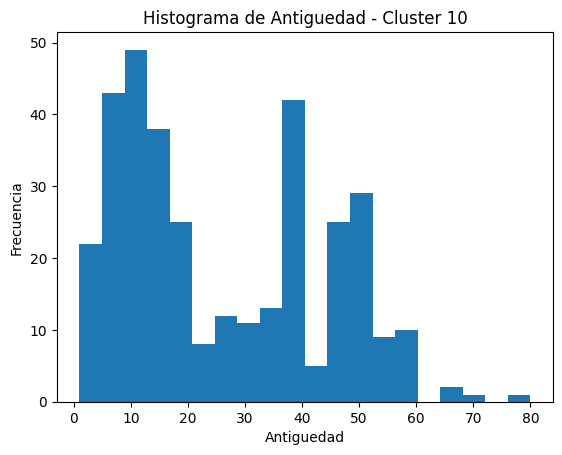

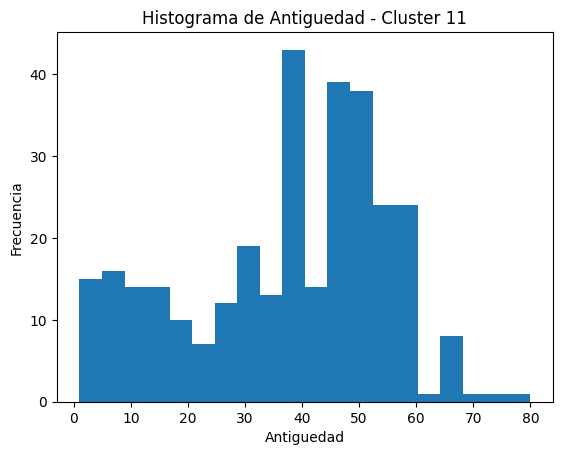

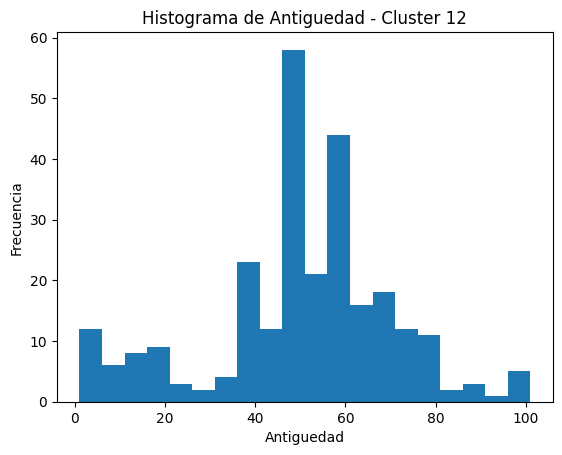

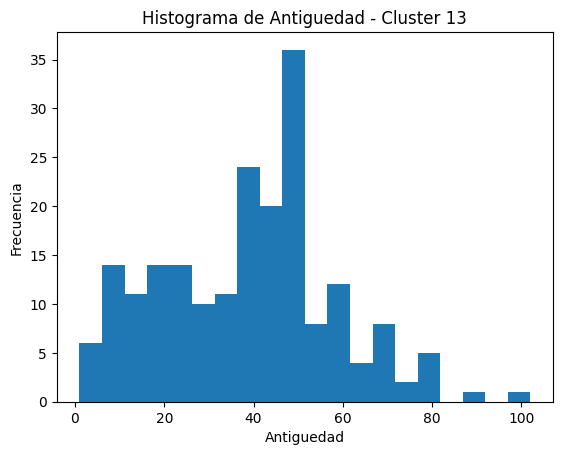

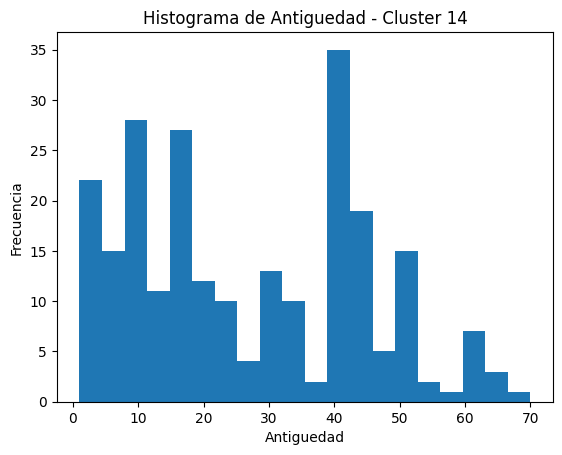

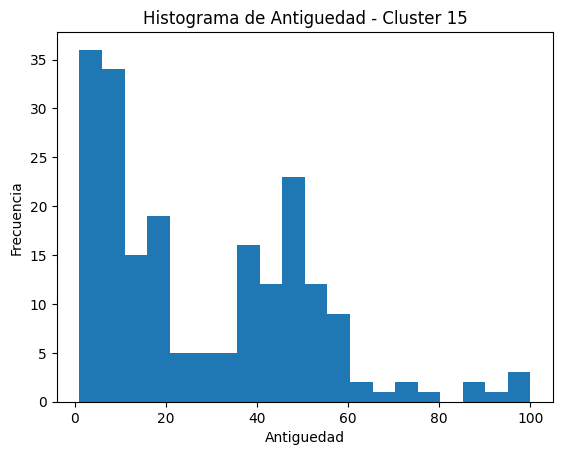

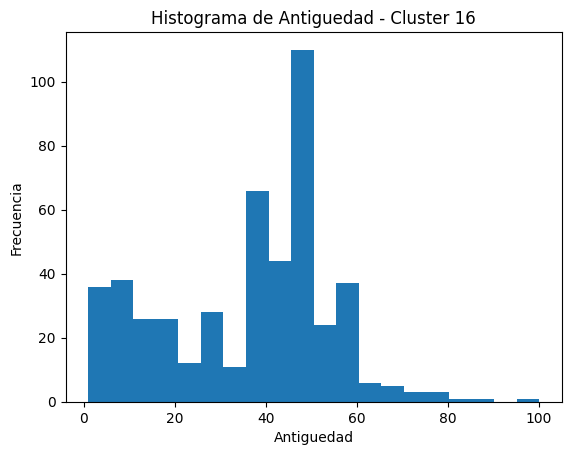

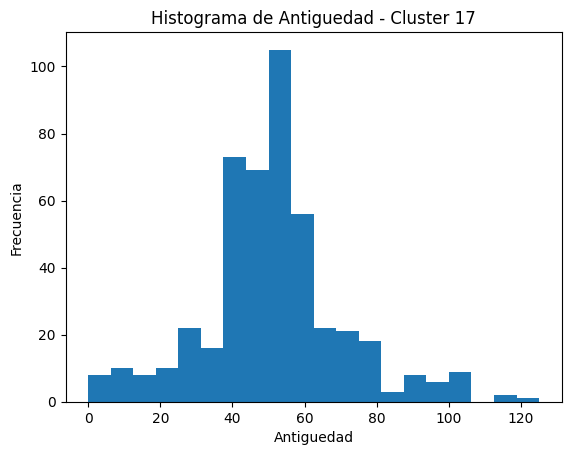

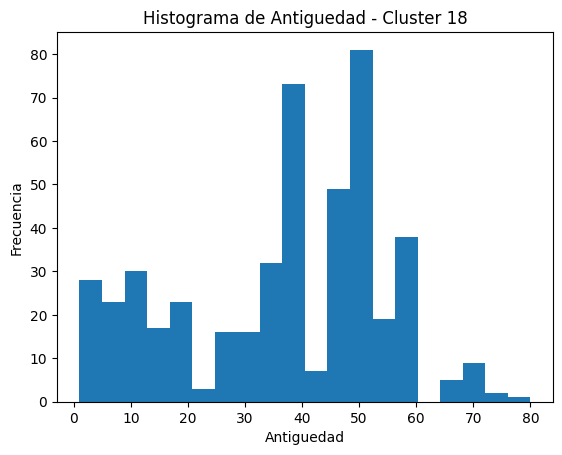

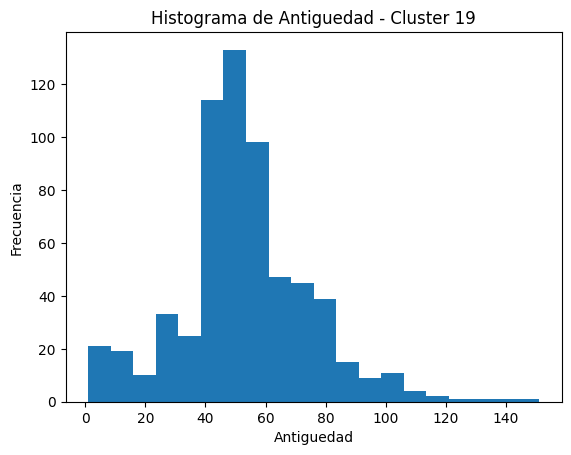

In [37]:
import matplotlib.pyplot as plt

# variables que querés ver
variables = ['Precio_m2', 'Antiguedad']

for var in variables:
    for c in sorted(df_clus['cluster'].unique()):
        plt.figure()
        subset = df_clus[df_clus['cluster'] == c]
        
        plt.hist(subset[var], bins=20)
        plt.title(f'Histograma de {var} - Cluster {c}')
        plt.xlabel(var)
        plt.ylabel('Frecuencia')
        plt.show()

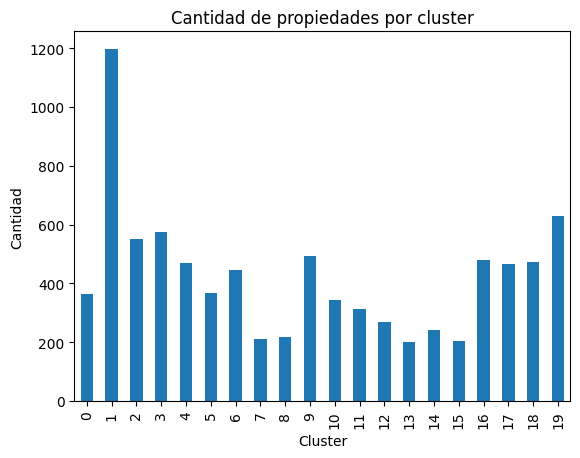

In [38]:
cluster_sizes = df_clus['cluster'].value_counts().sort_index()

plt.figure()
cluster_sizes.plot(kind='bar')
plt.title('Cantidad de propiedades por cluster')
plt.xlabel('Cluster')
plt.ylabel('Cantidad')
plt.show()

In [39]:
barrios = [col for col in df_clus.columns if 'Barrio_' in col]

df_barrios = df_clus.groupby('cluster')[barrios].mean()

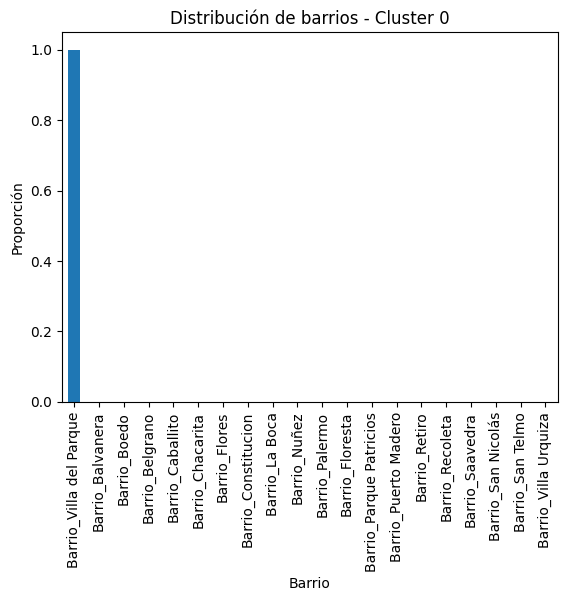

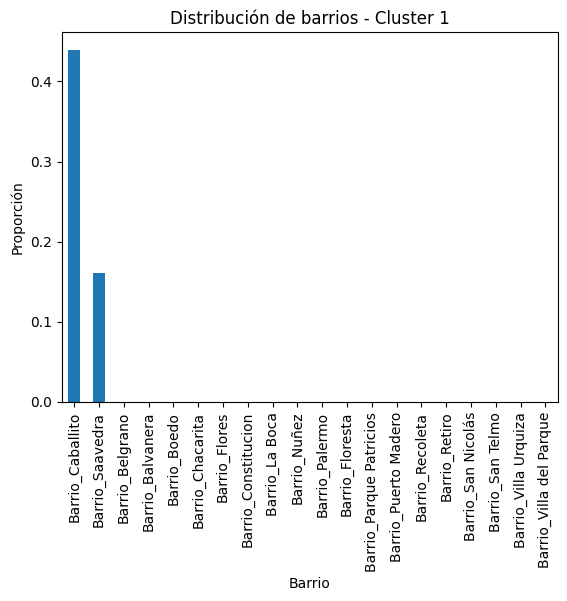

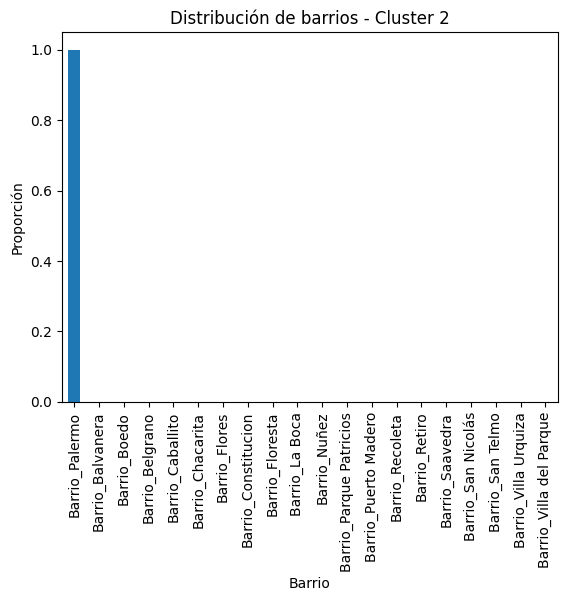

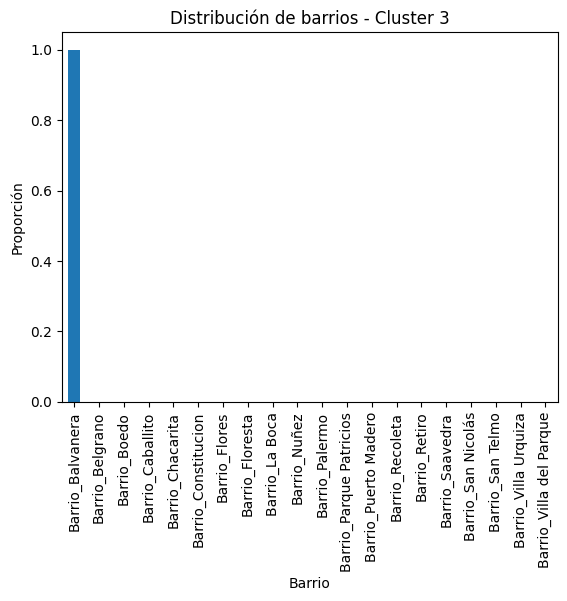

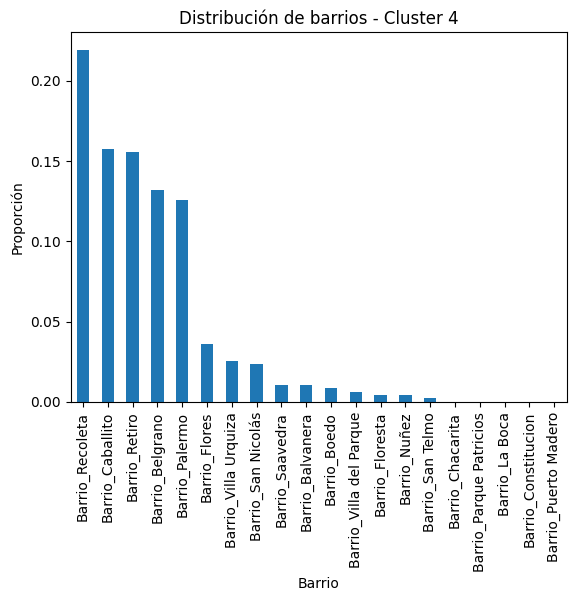

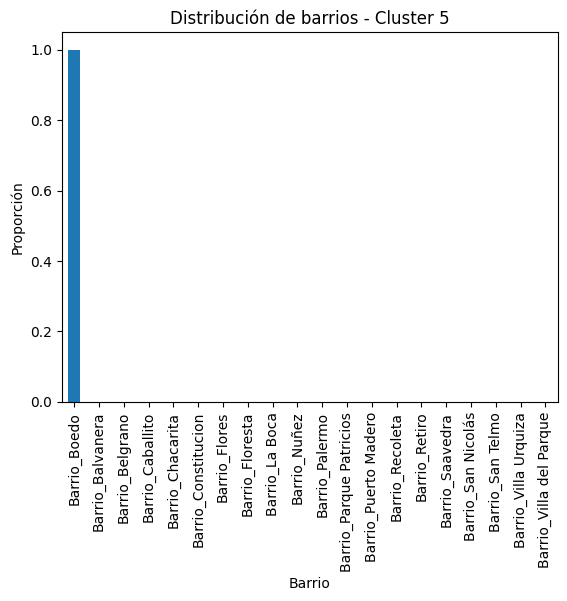

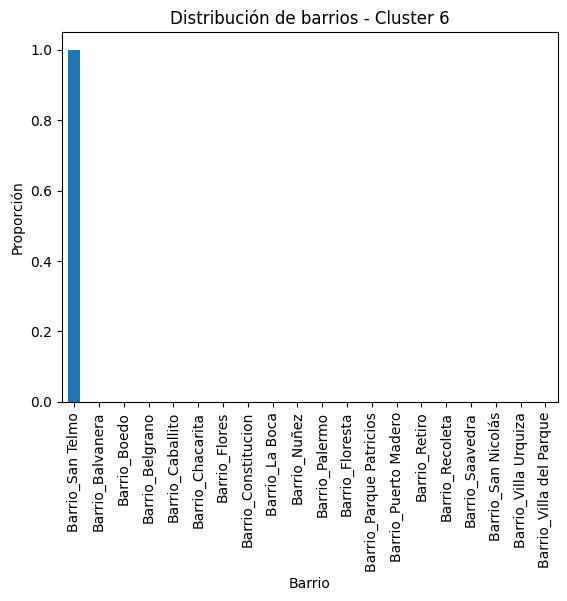

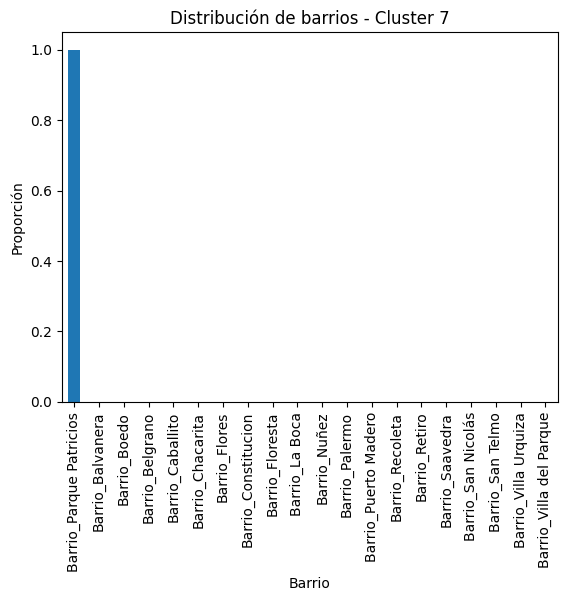

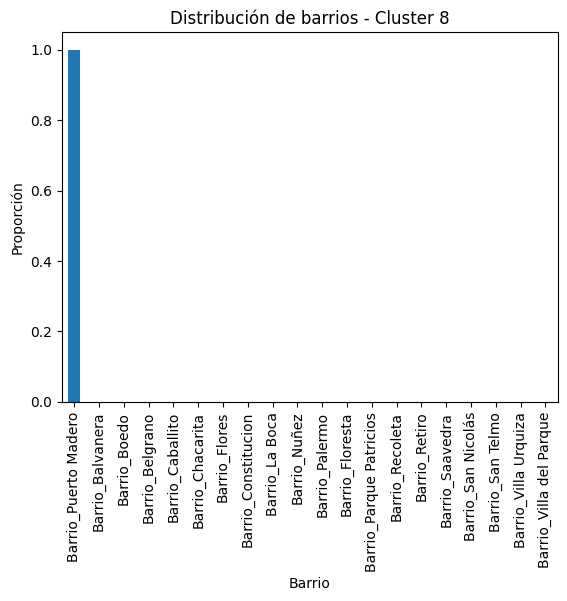

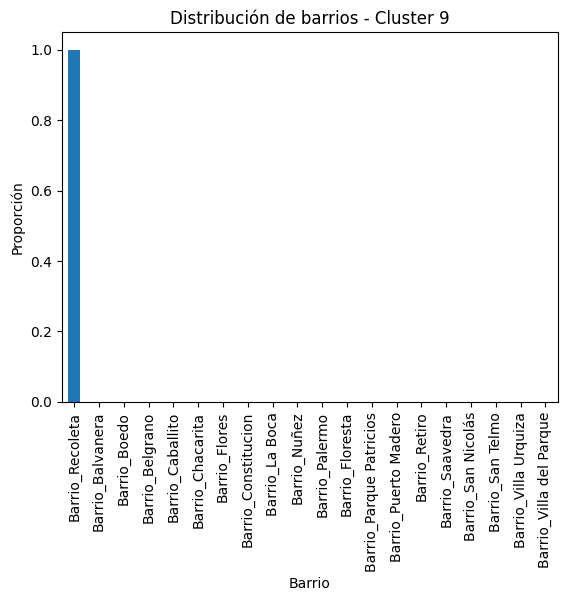

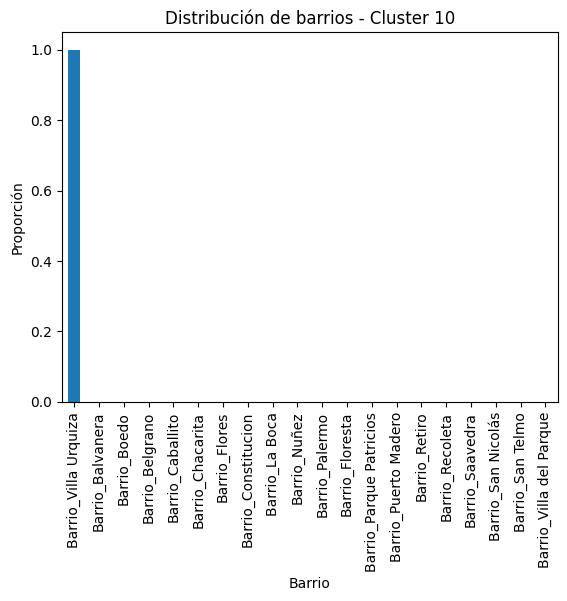

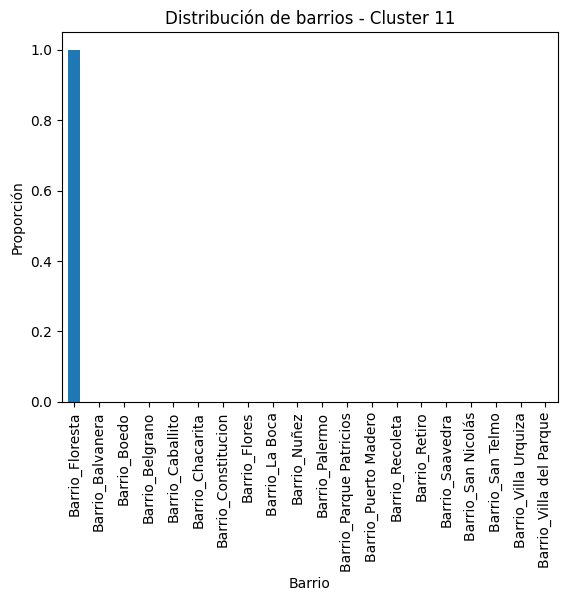

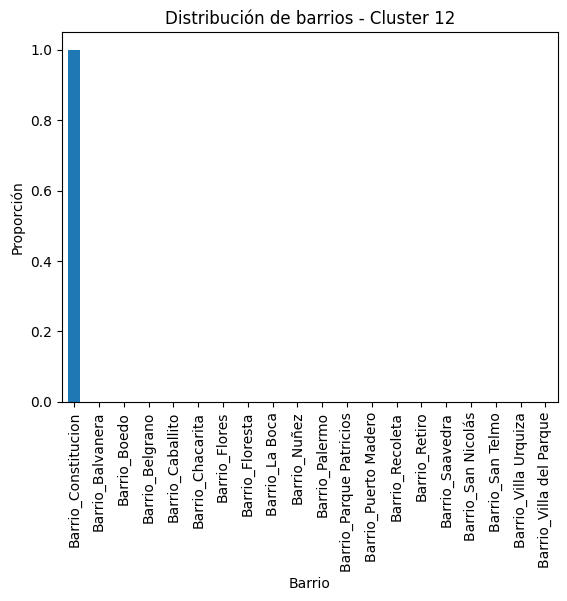

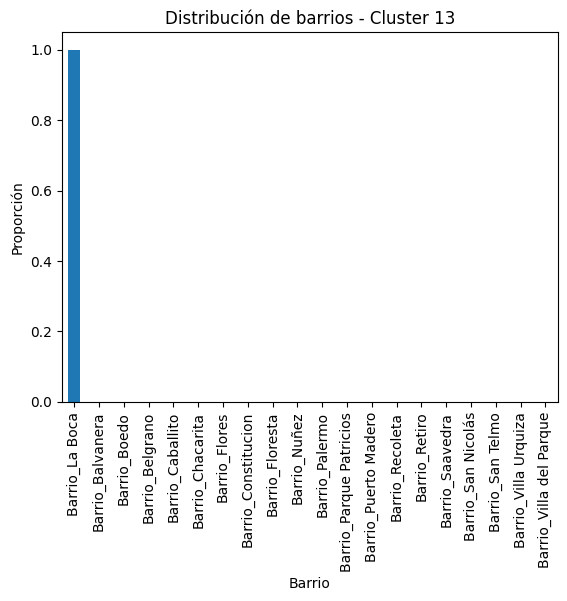

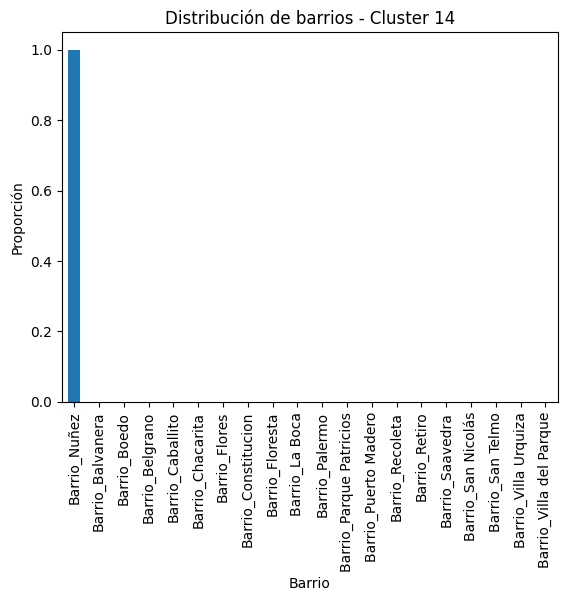

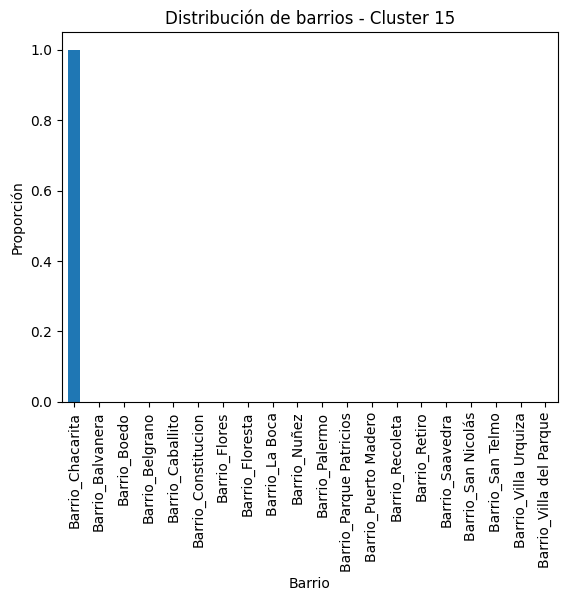

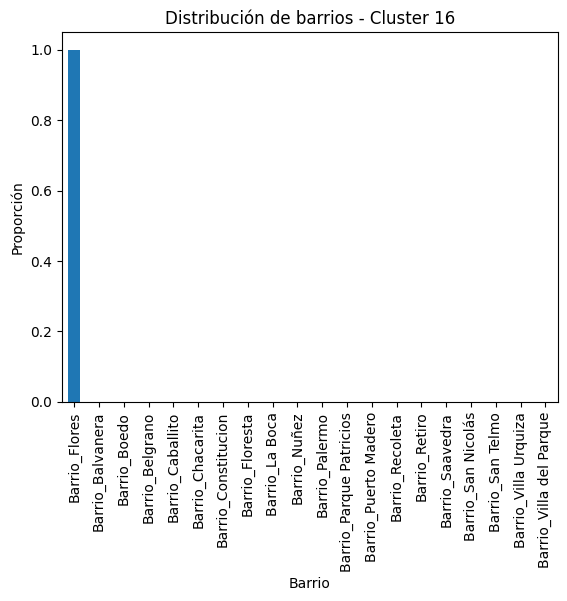

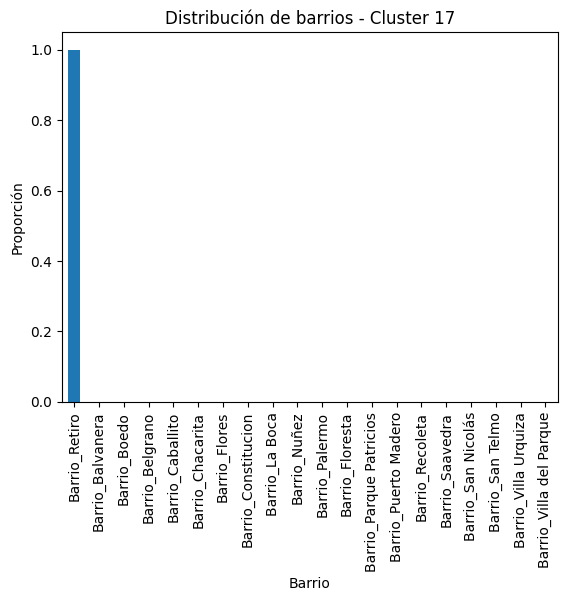

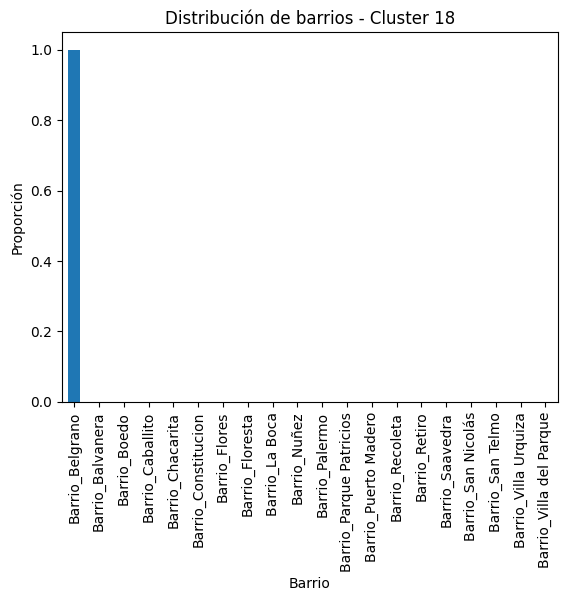

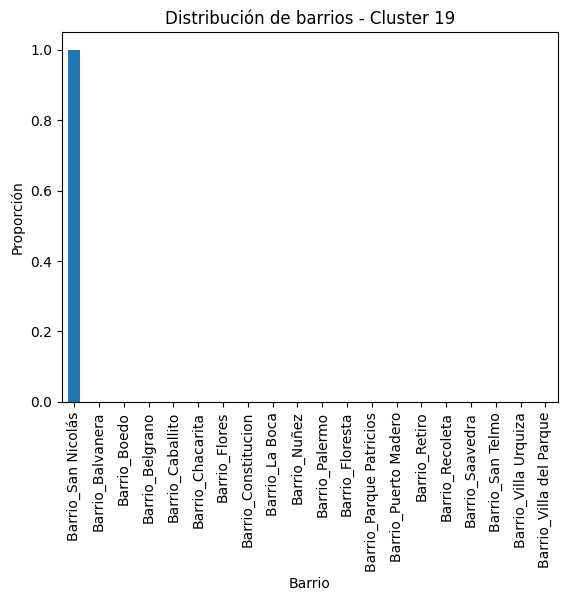

In [40]:
import matplotlib.pyplot as plt

for c in df_barrios.index:
    plt.figure()
    
    df_barrios.loc[c].sort_values(ascending=False).plot(kind='bar')
    
    plt.title(f'Distribución de barrios - Cluster {c}')
    plt.ylabel('Proporción')
    plt.xlabel('Barrio')
    plt.xticks(rotation=90)
    plt.show()

In [46]:
df_map = df_clus2.dropna(subset=['Antiguedad']).copy()
df_map = df_map.reset_index(drop=True)

In [47]:
df_map['cluster'] = df_clus['cluster']

In [48]:
import random

# generar colores random
colores = {}
clusters_unicos = df_map['cluster'].unique()

for c in clusters_unicos:
    colores[c] = "#{:06x}".format(random.randint(0, 0xFFFFFF))

In [49]:
df_map2 = df_map.dropna(subset=['Latitud', 'Longitud'])

In [55]:
import folium
mapa = folium.Map(location=[-34.6037, -58.3816], zoom_start=12)

In [56]:
for _, row in df_map2.iterrows():
    folium.CircleMarker(
        location=[row['Latitud'], row['Longitud']],
        radius=3,
        color=colores[row['cluster']],
        fill=True,
        fill_opacity=0.7
    ).add_to(mapa)

In [57]:
mapa.save("mapa_clusters.html")

Con este mapa podemos concluir que el barrio es un factor muy importante, algo que suponiamos desde el principio, el algoritmo de cluster separa muy bien los barrios, con lo cual tiene un alto peso

In [58]:
df_map.to_csv('df_map.csv', index=False)

Conclusion

PREMIUM


CLUSTER 2 — Palermo usado
Precio m2: $2.799 | Antigüedad: 36 años | Amenities: 37
→ Stock antiguo en barrio de alta demanda. Oportunidad de reciclaje y revalorización.

CLUSTER 8 — Puerto Madero Premium
Precio m2: $5.365 | Expensas: $497k | Amenities: 87% | Cochera: 78%
→ El segmento más exclusivo del mercado. Ticket alto, comprador sofisticado, inversión de resguardo de valor.

CLUSTER 14 — Núñez compacto
Precio m2: $2.894 | 1-2 dorm | Apto crédito: 55%
→ Departamentos chicos en barrio premium. Perfil inversor o primera vivienda con capacidad de financiamiento.

CLUSTER 18 — Belgrano residencial
Precio m2: $2.688 | 2 dorm | Apto crédito: 55%
→ Perfil familiar consolidado. Barrio seguro, buena liquidez.

MEDIO-ALTO


CLUSTER 4 — Multimercado medio-alto
Precio m2: $2.685 | 3 dorm | 150m2 | Cochera: 84%
→ Unidades familiares grandes dispersas en toda la ciudad. El segmento más heterogéneo, ideal para comparar entre barrios.

CLUSTER 9 — Recoleta envejecido
Precio m2: $2.592 | Antigüedad: 46 años | Amenities: 20%
→ Stock viejo en zona premium. Descuento por antigüedad pero ubicación top. Candidato a refacción.

CLUSTER 10 — Villa del Parque accesible
Precio m2: $2.474 | Apto crédito: 61% | Expensas bajas
→ Barrio residencial tranquilo. Perfil primera vivienda con crédito hipotecario.

MEDIO


CLUSTER 0 — Villa del Parque económico
Precio m2: $2.143 | Apto crédito: 51%
→ Segunda franja del barrio, precio más accesible. Perfil crédito hipotecario.

CLUSTER 1 — Caballito / San Nicolás mixto
Precio m2: $2.126 | Apto crédito: 58%
→ Dos barrios con perfil similar: demanda genuina, buena rotación, mercado líquido.

CLUSTER 15 — Chacarita en expansión
Precio m2: $2.336 | Amenities: 71% | A estrenar: 9%
→ Barrio en proceso de gentrificación. Alto porcentaje de amenities sugiere desarrollos nuevos.

CLUSTER 17 — Saavedra familiar
Precio m2: $2.293 | Antigüedad: 51 años | Proporción cubierta alta
→ Unidades grandes y antiguas en barrio tranquilo. Comprador final, no inversor.

ACCESIBLE


CLUSTER 5 — Boedo popular
Precio m2: $1.862 | Apto crédito: 60% | Expensas bajas
→ Barrio con precio accesible y alta proporción apta crédito. Perfil primera vivienda.

CLUSTER 6 — Villa Urquiza envejecido
Precio m2: $1.837 | Antigüedad: 52 años | Amenities: 23%
→ Stock viejo, precio bajo para el barrio. Oportunidad de entrada con potencial de mejora.

CLUSTER 11 — Floresta
Precio m2: $1.647 | Apto crédito: 64%
→ Barrio periférico accesible. El segmento más orientado a crédito hipotecario de toda la muestra.

CLUSTER 16 — Flores económico
Precio m2: $1.753 | 2 dorm | Apto crédito: 63%
→ Mercado de volumen. Alta proporción apta crédito, comprador de primera vivienda.

CLUSTER 19 — San Nicolás
Precio m2: $1.797 | Antigüedad: 53 años | Índice seguridad bajo
→ Zona céntrica con descuento por seguridad. Perfil inversor de renta.

DESCUENTO ESTRUCTURAL


CLUSTER 3 — Balvanera
Precio m2: $1.609 | Antigüedad: 51 años | Amenities: 18%
→ Stock viejo en zona densa. Precio bajo pero expensas moderadas. Perfil renta.

CLUSTER 7 — Puerto Madero bajo
Precio m2: $1.577 | Amenities: 51
→ Outliers dentro de Puerto Madero, probablemente unidades pequeñas o con algún problema. Vale la pena revisar.

CLUSTER 12 — Constitución
Precio m2: $1.322 | Antigüedad: 50 años | Índice seguridad muy bajo
→ Precio mínimo del mercado. Descuento estructural por percepción de inseguridad.

CLUSTER 13 — La Boca
Precio m2: $1.338 | Sin A estrenar | Seguridad baja
→ El segmento más barato. Alto riesgo, alta oportunidad especulativa a largo plazo